In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
#Load our dataset
data = pd.read_excel("Online Retail.xlsx")

In [5]:
#Display the basic info
print("The shape of the dataset:", data.shape)
print("\n")
print("First 5 rows")
display(data.head())

print("\n")
print("The data types and the non null values")
data.info()

The shape of the dataset: (541909, 8)


First 5 rows


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom




The data types and the non null values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 1. Data Loading and Initial Inspection

The dataset contains transaction-level records from an online retailer.

Initial inspection is used to understand the dataset structure, variable types, missing values, and the overall scale of the data before beginning data cleaning.

In [9]:
#Look out for missing values
print("Missing values:")
display(data.isnull().sum())

Missing values:


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
#Look for duplicate rows
print("\n Duplicate rows:", data.duplicated().sum())



 Duplicate rows: 5268


In [11]:
#Look for cancelled invoices
cancel_inv = data["InvoiceNo"].astype(str).str.startswith("C")
print("\n Cancelled transactions:", cancel_inv.sum())


 Cancelled transactions: 9288


In [14]:
#Look for unusual quantities and prices
print("\nQuantity summary:")
display(data["Quantity"].describe())

print("\nUnit price summary:")
display(data["UnitPrice"].describe())


Quantity summary:


count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64


Unit price summary:


count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [18]:
#Analayse the cancelled transcations 
cancel_data = data[data["InvoiceNo"].astype(str).str.startswith("C")]

print("Cancelled transaction summary:")
display(cancel_data[['Quantity', "UnitPrice"]].describe())



Cancelled transaction summary:


,Quantity,UnitPrice
count,9288.000000,9288.000000
mean,-29.885228,48.393661
std,1145.786965,666.600430
min,-80995.000000,0.010000
25%,-6.000000,1.450000
50%,-2.000000,2.950000
75%,-1.000000,5.950000
max,-1.000000,38970.000000


In [20]:
#Analyse non-cancelled transactions with negative quantity 
neg_qty = data[
    ~data["InvoiceNo"].astype(str).str.startswith("C")&
    (data["Quantity"] < 0)
]

print("\nNegative quantities in non-cancelled invoices:", len(neg_qty))
display(neg_qty.head(10))



Negative quantities in non-cancelled invoices: 1336


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


In [22]:
#Anlayse zero or negative prices
neg_prices = data[data["UnitPrice"] <= 0]

print("\nTransactions with zero or negative UnitPrice:", len(neg_prices))
display(neg_prices.head(10))



Transactions with zero or negative UnitPrice: 2517


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


## 2. Data Cleaning

The transaction data was checked for cancellations, duplicate records, missing values, and invalid quantities or prices.

Because the analysis focuses on completed sales, cancelled invoices and transactions with non-positive quantities or prices were excluded from sales calculations.

Missing customer IDs were retained for overall sales analysis because they do not prevent revenue from being calculated. Customer-level analysis will use only transactions with available customer identifiers.

In [23]:
#Create a copy for the cleaning process
clean_data = data.copy()

In [25]:
#Delete the cancelled invoices
clean_data = clean_data[
    ~clean_data["InvoiceNo"].astype(str).str.startswith('C')
]

#Delete the negative quantities
clean_data = clean_data[clean_data["Quantity"] > 0]

#Delete the negative prices
clean_data = clean_data[clean_data["UnitPrice"] > 0]

#Delete duplicate rows
clean_data = clean_data.drop_duplicates()

In [26]:
#Calculate revenue for each transaction
clean_data["Revenue"] = clean_data["Quantity"] * clean_data["UnitPrice"]

print("Original dataset:", data.shape)
print("Cleaned sales dataset:", clean_data.shape)

print("\nRemaining missing values:")
display(clean_data.isnull().sum())

print("\nRevenue summary:")
display(clean_data["Revenue"].describe())

Original dataset: (541909, 8)
Cleaned sales dataset: (524878, 9)

Remaining missing values:


InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64


Revenue summary:


count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

## 3. Key Business Metrics

Key performance indicators were calculated from the cleaned transaction data to provide an overview of sales performance.

The analysis focuses on total revenue, number of orders, number of customers, average order value, and the overall sales period.

In [27]:
#Calculate important business metrics

total_rev = clean_data["Revenue"].sum()
total_ord = clean_data["InvoiceNo"].nunique()
total_cust = clean_data["CustomerID"].nunique()
avg_ord_val = clean_data.groupby("InvoiceNo")["Revenue"].sum().mean()

start = clean_data["InvoiceDate"].min()
end = clean_data["InvoiceDate"].max()

print(f"Total revenue: £{total_rev:,.2f}")
print(f"Total orders: {total_ord:,}")
print(f"Unique customers: {total_cust:,}")
print(f"Average order value: £{avg_ord_val:,.2f}")
print(f"Sales period: {start} to {end}")

Total revenue: £10,642,110.80
Total orders: 19,960
Unique customers: 4,338
Average order value: £533.17
Sales period: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [28]:
kpi_table = pd.DataFrame({
    "Metrics": [
        "Revenue",
        "Orders",
        "Unique Customers",
        "Avg Order Value"
        
    ],
    
    "Values": [
         f"£{total_rev:,.2f}",
        f"{total_ord:,}",
        f"{total_cust:,}",
        f"£{avg_ord_val:,.2f}"
    ]
        
})


display(kpi_table)

,Metrics,Values
0,Revenue,"£10,642,110.80"
1,Orders,"19,960"
2,Unique Customers,"4,338"
3,Avg Order Value,£533.17


## 4. Monthly Revenue Analysis

Monthly revenue was calculated to identify trends and changes in sales performance over the period covered by the dataset.

Monthly aggregation helps reveal seasonal patterns and periods of particularly strong or weak sales activity.

In [30]:
#Month column
clean_data["Month"] = clean_data["InvoiceDate"].dt.to_period("M").astype(str)



In [31]:
#Calculate the monthly revenue for the business

monthly_rev = (
    clean_data.groupby("Month")["Revenue"]
    .sum()
    .reset_index()
)

display(monthly_rev)

,Month,Revenue
0,2010-12,821452.730
1,2011-01,689811.610
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,757841.380
9,2011-09,1056435.192


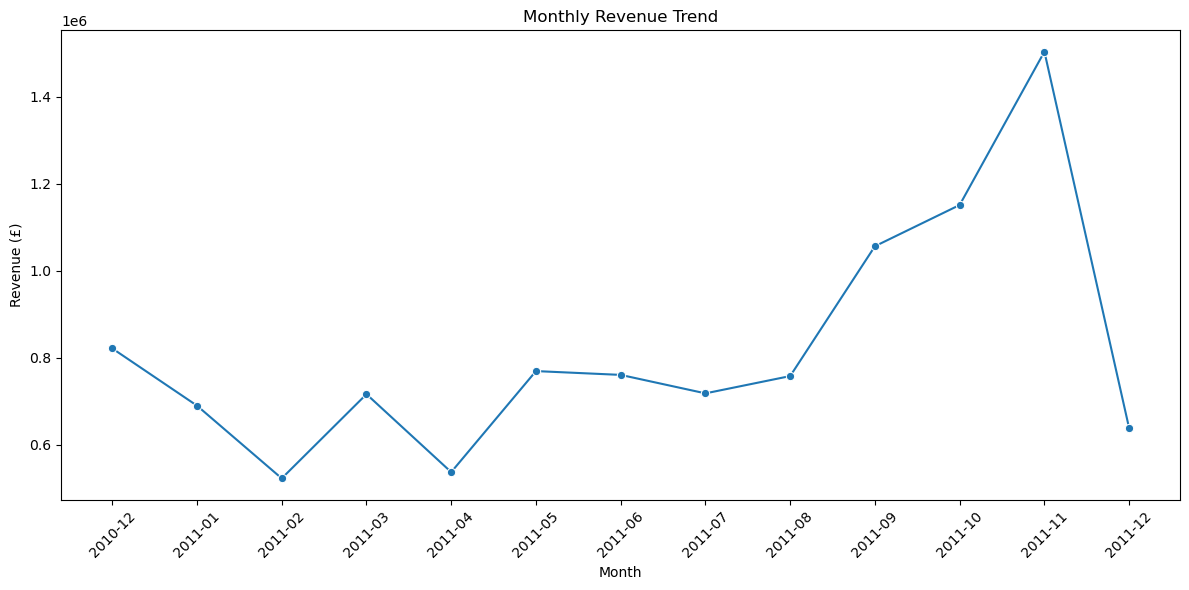

In [54]:
#Plot the chart 
plt.figure(figsize=(12,6))

sns.lineplot(
    data = monthly_rev,
    x= "Month",
    y = "Revenue",
    marker = "o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("images/monthly_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Findings

Revenue fluctuated throughout the period, with the strongest performance occurring in **November 2011**. Revenue increased substantially from August through November, suggesting a strong late-year sales period.

February 2011 recorded the lowest monthly revenue among the complete months shown. December 2011 shows a sharp decline, but this month is incomplete because the dataset ends on **9 December 2011**, so it should not be directly compared with the full preceding months.

## 5. Product Performance

Product-level revenue was analysed to identify the products that contributed most strongly to overall sales.

Revenue was calculated by multiplying quantity purchased by unit price and then aggregating the result by product.

In [35]:
#Calculate revenue for each product

prod_rev = (
clean_data.groupby(["StockCode", "Description"])["Revenue"]
.sum()
.sort_values(ascending=False)
.reset_index()

)

#Show the top 10 products
display(prod_rev.head(10))

,StockCode,Description,Revenue
0,DOT,DOTCOM POSTAGE,206248.77
1,22423,REGENCY CAKESTAND 3 TIER,174156.54
2,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24
4,47566,PARTY BUNTING,99445.23
5,85099B,JUMBO BAG RED RETROSPOT,94159.81
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,POST,POSTAGE,78101.88
8,M,Manual,77750.27
9,23084,RABBIT NIGHT LIGHT,66870.03


In [36]:
#Analyse product description with the transaction frequency

prod_cnt = (
    clean_data.groupby(["StockCode", "Description"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="TransactionLines")

)

display(prod_cnt.head(20))

,StockCode,Description,TransactionLines
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2244
1,85099B,JUMBO BAG RED RETROSPOT,2109
2,22423,REGENCY CAKESTAND 3 TIER,2007
3,47566,PARTY BUNTING,1699
4,20725,LUNCH BAG RED RETROSPOT,1581
5,84879,ASSORTED COLOUR BIRD ORNAMENT,1476
6,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1392
7,21212,PACK OF 72 RETROSPOT CAKE CASES,1352
8,20727,LUNCH BAG BLACK SKULL.,1301
9,22457,NATURAL SLATE HEART CHALKBOARD,1255


In [37]:
#Analyse entries with odd stock names
odd_codes = ["POST", "DOT", "M", "BANK CHARGES", "AMAZON FEE", 
                 "ADJUST", "CRUK Commission", "C2", "D", "S", "SAMPLES", "PADS"]

display(
prod_rev[
    prod_rev["StockCode"].astype(str).isin(odd_codes)
])

,StockCode,Description,Revenue
0,DOT,DOTCOM POSTAGE,206248.770
7,POST,POSTAGE,78101.880
8,M,Manual,77750.270
350,C2,CARRIAGE,7051.000
2920,BANK CHARGES,Bank Charges,165.001
3374,S,SAMPLES,63.050
4160,PADS,PADS TO MATCH ALL CUSHIONS,0.003


In [38]:
#Remove the non-product entries

non_prod_codes = [
    "POST", "DOT", "M", "BANK CHARGES",
    "AMAZON FEE", "ADJUST", "CRUK Commission",
    "C2", "D", "S", "SAMPLES", "PADS"
]

#keep the real products
prod = prod_rev[
    ~prod_rev["StockCode"].astype(str).isin(non_prod_codes)

].copy()

#top 10 products by their revenue
top_prod = prod.head(10)

display(top_prod)

,StockCode,Description,Revenue
1,22423,REGENCY CAKESTAND 3 TIER,174156.54
2,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24
4,47566,PARTY BUNTING,99445.23
5,85099B,JUMBO BAG RED RETROSPOT,94159.81
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
9,23084,RABBIT NIGHT LIGHT,66870.03
10,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
11,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62
12,79321,CHILLI LIGHTS,54096.36


### Top Products by Revenue

The top-selling products were ranked by total revenue after excluding non-product transaction entries such as postage, manual adjustments, and bank charges.

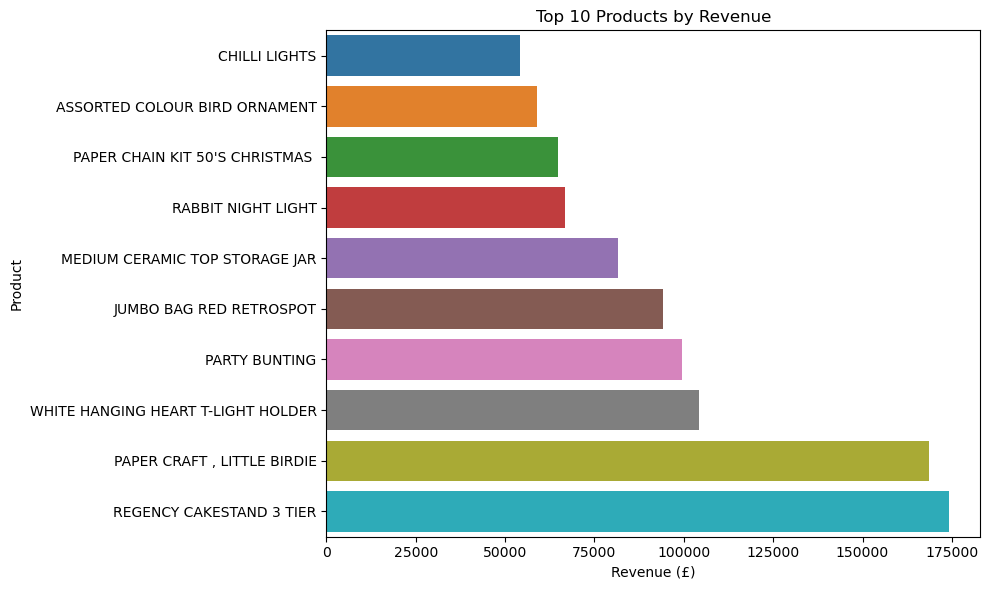

In [55]:
#Take the top 10 products
top_10 = prod.head(10).sort_values("Revenue",ascending=True)

#Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10,
    x="Revenue",
    y="Description"


)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()

plt.savefig("images/top_products.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Findings

REGENCY CAKESTAND 3 TIER generated the highest revenue among the identified retail products, followed closely by PAPER CRAFT, LITTLE BIRDIE.

The remaining products in the top 10 generated substantially less revenue, with CHILLI LIGHTS recording the lowest revenue within this group.

### Key Findings

REGENCY CAKESTAND 3 TIER generated the highest revenue among the identified retail products, followed closely by PAPER CRAFT, LITTLE BIRDIE.

The remaining products in the top 10 generated substantially less revenue, with CHILLI LIGHTS recording the lowest revenue within this group.

In [42]:
#Calculate the revenue for each country

country_rev = (
    clean_data.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(country_rev.head(15))

,Country,Revenue
0,United Kingdom,9001744.094
1,Netherlands,285446.340
2,EIRE,283140.520
3,Germany,228678.400
4,France,209625.370
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,57067.600
8,Belgium,41196.340
9,Sweden,38367.830


### Revenue by Country

The highest-revenue countries were compared to identify the main geographic markets represented in the dataset.

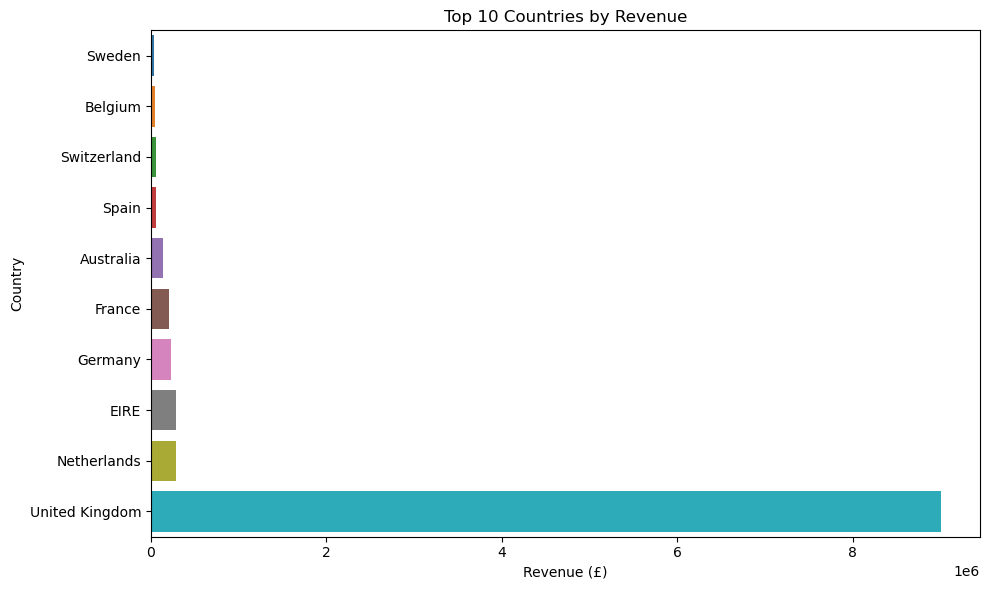

In [56]:
#Take the top 10 countries
top_10_cntr = country_rev.head(10).sort_values(
    "Revenue",
    ascending=True

)

#Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data= top_10_cntr,
    x="Revenue",
    y="Country"

)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()

plt.savefig("images/country_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### Key Findings

The United Kingdom was by far the largest market in the dataset, generating approximately **£9.00 million** in revenue.

The Netherlands was the second-highest market at approximately **£285,000**, followed by Ireland and Germany. This indicates that sales were highly concentrated in the UK, with substantially smaller contributions from other countries.

## 7. Customer Analysis

Customer-level spending was analysed using transactions with available customer identifiers.

The analysis examines the distribution of customer spending and whether revenue is concentrated among a relatively small number of customers.

In [46]:
#Only keep the transactions with a known customer
customer_data = clean_data.dropna(subset=["CustomerID"]).copy()


In [47]:
#Calculate the revenue for each customer

customer_rev = (
    customer_data.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()

)

#Show top 10 customers
display(customer_rev.head(10))

,CustomerID,Revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194390.79
3,16446.0,168472.50
4,14911.0,143711.17
5,12415.0,124914.53
6,14156.0,117210.08
7,17511.0,91062.38
8,16029.0,80850.84
9,12346.0,77183.60


### Customer Spending Distribution

Customer revenue was examined to understand the distribution of spending across customers.

A histogram is used to show how customer spending is distributed and whether a small number of customers account for unusually high levels of revenue.

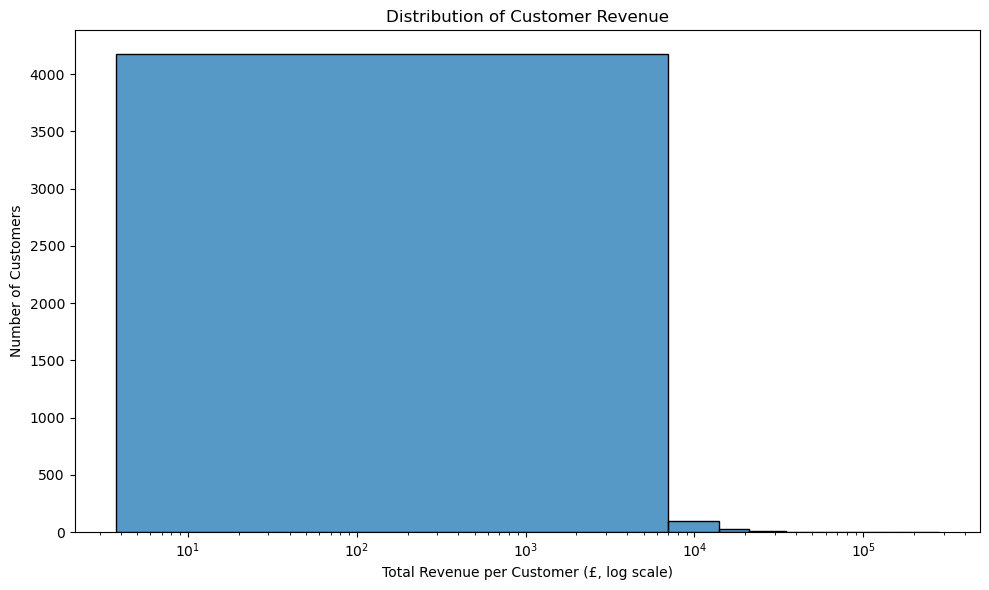

In [50]:
# Plot
plt.figure(figsize=(10, 6))

sns.histplot(
    customer_rev["Revenue"],
    bins=40
)

plt.xscale("log")

plt.title("Distribution of Customer Revenue")
plt.xlabel("Total Revenue per Customer (£, log scale)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [52]:
#Calculate the shre of revenue by the top 10 customers

customer_rev_sort = customer_rev.sort_values(
    "Revenue",
    ascending=False
).reset_index(drop=True)

top_10_count = int(np.ceil(len(customer_rev_sort) * 0.10))

top_10_rev = customer_rev_sort.head(top_10_count)["Revenue"].sum()
total_cust_rev = customer_rev_sort["Revenue"].sum()


top_10_share = (top_10_rev / total_cust_rev) * 100


print(f"Number of customers analysed: {len(customer_rev_sort):,}")
print(f"Top 10% of customers: {top_10_count:,}")
print(f"Revenue generated by top 10%: £{top_10_rev:,.2f}")
print(f"Top 10% revenue share: {top_10_share:.1f}%")

Number of customers analysed: 4,338
Top 10% of customers: 434
Revenue generated by top 10%: £5,461,374.89
Top 10% revenue share: 61.5%


### Key Findings

Customer revenue was highly concentrated among a relatively small group of customers. The top 10% of customers accounted for **61.5% of total customer-attributed revenue**, highlighting the importance of high-value customers to overall sales.

This concentration suggests that customer retention and engagement among high-value customers could have a meaningful impact on revenue.

## 8. Overall Insights

The analysis identified several key patterns in the online retail dataset:

- **Sales growth:** Monthly revenue fluctuated throughout the period, with revenue increasing substantially from August to November 2011. November recorded the highest monthly revenue, while December was incomplete because the dataset ended on 9 December 2011.

- **Product performance:** REGENCY CAKESTAND 3 TIER generated the highest revenue among the identified retail products, followed by PAPER CRAFT, LITTLE BIRDIE.

- **Geographic concentration:** The United Kingdom was by far the largest market, generating approximately £9.00 million in recorded revenue. The Netherlands was the second-highest market at approximately £285,000.

- **Customer concentration:** Among customers with available CustomerID values, the top 10% of customers accounted for 61.5% of customer-attributed revenue.

Overall, the analysis shows that revenue was concentrated geographically, across a relatively small group of high-value customers, and among a limited number of high-performing products.